In [1]:
# A lot of this python notebook was created by AI due to time constraints.
# I am planning on going through this and redoing most of this if necessary at a later date.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.signal import find_peaks

from collections import defaultdict

In [3]:
# The first two functions are defined in the report
# find_peaks can be found at https://pythonguides.com/scipy-find-peaks/

def calculateSkewKurtosisPeaks (count, Q, prominence = 0.1):
    
    shots = sum (count.values())
    p = np.zeros (Q)
    
    for bitstring, c in count.items():
        y = int (bitstring, 2)
        p[y] = c / shots

    yVals = np.arange (Q)
    mean = np.sum (p * yVals)
    var = np.sum (p * (yVals - mean)**2)
    std = np.sqrt (var) if var > 0 else 1e-12

    skewness = np.sum (p * (yVals - mean)**3) / std**3
    kurt = np.sum (p * (yVals - mean)**4) / std**4 - 3

    peakProminence = prominence * p.max()
    pTiled = np.tile (p, 3)
    peaks, _ = find_peaks (pTiled, prominence = peakProminence)
    numPeaks = len (peaks[(peaks >= Q) & (peaks < 2 * Q)])

    return skewness, kurt, numPeaks

In [4]:
simulatorDataset = []

with open (f"simulatorDataset.json", "r") as f:
    simulatorDataset.extend (json.load (f))

tempdf = pd.DataFrame (simulatorDataset)
simulatordf = tempdf[tempdf["noise"] != "Ideal"].copy()

results = simulatordf.apply (lambda row: calculateSkewKurtosisPeaks (row["counts"], row["Q"]), axis = 1)

simulatordf["skewness"] = results.apply (lambda x: x[0])
simulatordf["kurtosis"] = results.apply (lambda x: x[1])
simulatordf["numPeaks"] = results.apply (lambda x: x[2])

print (len (simulatorDataset))
print (len (simulatordf))

600
480


In [5]:
def printSingleFeatureAUROC (X, y):
    
    invert = {"Hnorm", "numPeaks"}
    
    for col in X.columns:
        score = -X[col] if col in invert else X[col]
        print (col, roc_auc_score (y, score))

In [6]:
def plotRecoverability(df, savename):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    colors = df["recoverable"].map({True: "tab:blue", False: "orange"})

    # (a) Hnorm vs Apeak
    axes[0].scatter(df["Hnorm"], df["Apeak"], c=colors, alpha=0.6, s=15)
    axes[0].set_xlabel("Normalized entropy $H_{norm}$")
    axes[0].set_ylabel("Autocorrelation peak strength $A_{peak}$")
    axes[0].set_title("(a) Histogram-level structure")

    # (b) M1frac vs DeltaVerFrac
    axes[1].scatter(df["DeltaVerFrac"], df["M1frac"], c=colors, alpha=0.6, s=15)
    axes[1].set_xlabel("Verified margin fraction $\\Delta_{ver,frac}$")
    axes[1].set_ylabel("Dominant verified mass fraction $M_{1,frac}$")
    axes[1].set_title("(b) Verified-candidate organization")

    # shared legend
    import matplotlib.patches as mpatches
    handles = [
        mpatches.Patch(color="orange", label="Not recovered"),
        mpatches.Patch(color="tab:blue", label="Recovered"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout()
    plt.savefig(f"{savename}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
def plotMarginalFeatureDistributions(df, features, savename, ncols=4):
    n = len(features)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten()

    for i, feat in enumerate(features):
        ax = axes[i]
        rec = df[df["recoverable"] == True][feat]
        non = df[df["recoverable"] == False][feat]
        ax.hist(non, bins=20, density=True, alpha=0.6, color="orange", label="Not recoverable")
        ax.hist(rec, bins=20, density=True, alpha=0.6, color="tab:blue", label="Recoverable")
        ax.axvline(non.median(), color="orange", linestyle="--")
        ax.axvline(rec.median(), color="tab:blue", linestyle="--")
        ax.set_title(feat)
        ax.legend(fontsize=8)

    # hide any unused subplot slots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(f"{savename}.png", dpi=150)
    plt.show()

In [8]:
def printMultivariableTreeClassifier (X, y):

    tree = DecisionTreeClassifier (max_depth = 4, random_state = 0).fit (X, y)
    print (export_text (tree, feature_names = list (X.columns)))

In [9]:
def printInterpretableDecisionTree (df, features, X, y):

    rf = RandomForestClassifier (n_estimators = 200, random_state = 0)
    cv = StratifiedKFold (n_splits = 5, shuffle = True, random_state = 0)
    scores = cross_val_score (rf, df[features], df["recoverable"].astype (int), cv = cv, scoring = "roc_auc")
    print (scores.mean(), scores.std())

In [10]:
def printCVPermutationImportance(X, y, n_splits=5, n_repeats=30, random_state=0):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_importances = {col: [] for col in X.columns}

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        rf = RandomForestClassifier(n_estimators=200, random_state=random_state)
        rf.fit(X_train, y_train)

        result = permutation_importance(
            rf, X_test, y_test,
            n_repeats=n_repeats,
            random_state=random_state,
            scoring="roc_auc"
        )

        for i, col in enumerate(X.columns):
            fold_importances[col].append(result.importances_mean[i])

    means = {col: np.mean(vals) for col, vals in fold_importances.items()}
    stds = {col: np.std(vals) for col, vals in fold_importances.items()}
    return means, stds

In [11]:
def plotPermutationImportanceFigure(X, y, savename="figure5"):
    means, stds = printCVPermutationImportance(X, y)

    # sort descending by importance, matching the paper's layout
    sorted_features = sorted(means, key=means.get, reverse=True)
    sorted_means = [means[f] for f in sorted_features]
    sorted_stds = [stds[f] for f in sorted_features]

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(sorted_features) + 1.5))
    y_pos = np.arange(len(sorted_features))

    ax.barh(y_pos, sorted_means, xerr=sorted_stds, color="steelblue", capsize=4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features)
    ax.invert_yaxis()  # highest importance at top, matching the figure
    ax.set_xlabel("Permutation importance (AUROC decrease)")
    ax.set_title("Multivariate feature importance\nfrom a random-forest model", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{savename}.png", dpi=150)
    plt.show()

    return means, stds

In [12]:
simX = simulatordf[["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]]
simy = simulatordf["recoverable"].astype (int)
features = ["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]

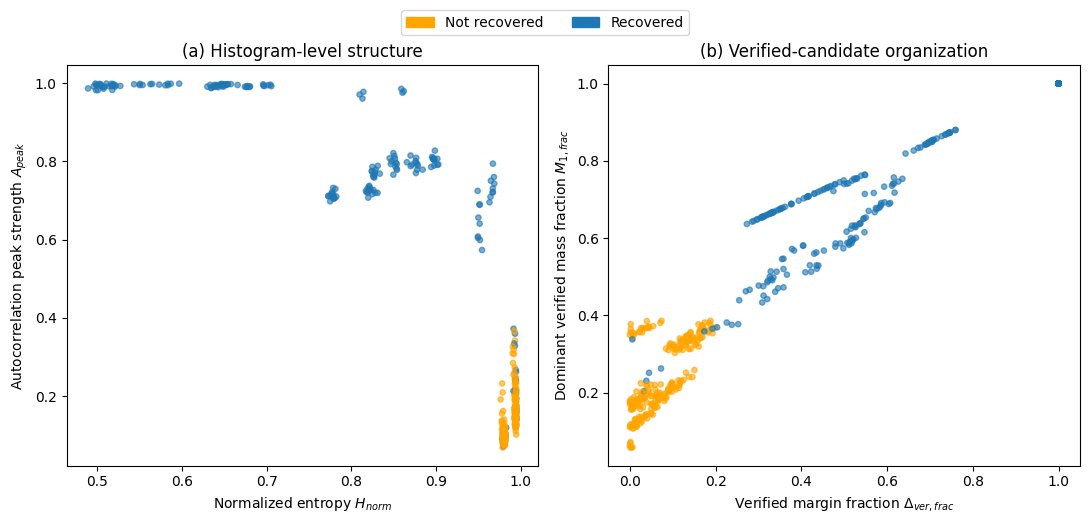

In [13]:
plotRecoverability(simulatordf, savename="figure2simulator")

In [14]:
printSingleFeatureAUROC (simX, simy)

Apeak 0.8673414469001198
Hnorm 0.8603621590652615
M1frac 0.9902602475737426
DeltaVerFrac 0.9866317123561175
skewness 0.8261601763919512
kurtosis 0.5955311724161878
numPeaks 0.854936717651348


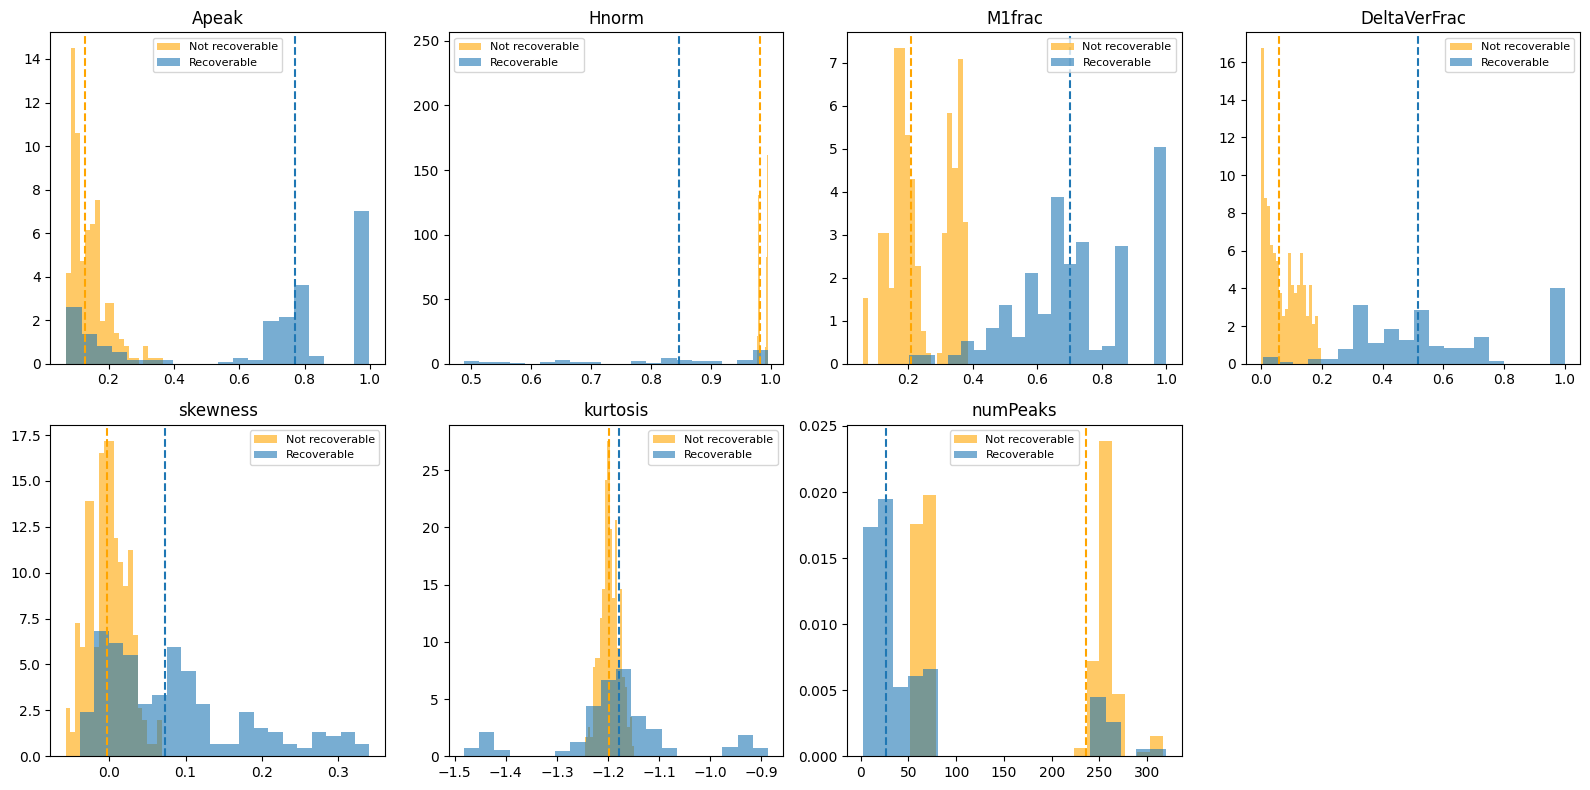

In [15]:
plotMarginalFeatureDistributions (simulatordf, features, "figure3simulator")

In [16]:
printMultivariableTreeClassifier (simX, simy)

|--- DeltaVerFrac <= 0.20
|   |--- Apeak <= 0.37
|   |   |--- numPeaks <= 53.50
|   |   |   |--- DeltaVerFrac <= 0.04
|   |   |   |   |--- class: 0
|   |   |   |--- DeltaVerFrac >  0.04
|   |   |   |   |--- class: 1
|   |   |--- numPeaks >  53.50
|   |   |   |--- Apeak <= 0.33
|   |   |   |   |--- class: 0
|   |   |   |--- Apeak >  0.33
|   |   |   |   |--- class: 0
|   |--- Apeak >  0.37
|   |   |--- class: 1
|--- DeltaVerFrac >  0.20
|   |--- class: 1



In [17]:
printInterpretableDecisionTree (simulatordf, features, simX, simy)

0.9956597222222221 0.006105769741939953


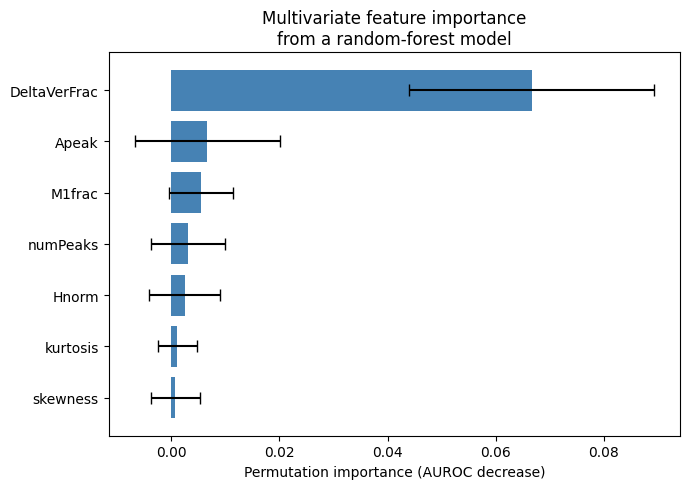

In [18]:
means, stds = plotPermutationImportanceFigure(simX, simy, savename="figure5simulator")

In [19]:
for feat in sorted(means, key=means.get, reverse=True):
    print(f"{feat:15s} {means[feat]:.4f} ± {stds[feat]:.4f}")

DeltaVerFrac    0.0666 ± 0.0226
Apeak           0.0067 ± 0.0134
M1frac          0.0056 ± 0.0059
numPeaks        0.0031 ± 0.0068
Hnorm           0.0025 ± 0.0065
kurtosis        0.0012 ± 0.0035
skewness        0.0008 ± 0.0045


In [20]:
backendDataset = []

for N in [3, 7, 15, 31, 63]:

    with open (f"backendDatasetN{N}.json", "r") as f:
        backendDataset.extend (json.load (f))

backenddf = pd.DataFrame (backendDataset)

results = backenddf.apply (lambda row: calculateSkewKurtosisPeaks(row["counts"], row["Q"]), axis = 1)
backenddf["skewness"] = results.apply (lambda x: x[0])
backenddf["kurtosis"] = results.apply (lambda x: x[1])
backenddf["numPeaks"] = results.apply (lambda x: x[2])

print (len (backendDataset))
print (len (backenddf))

384
384


In [21]:
numRecoverable = sum (exp["recoverable"] for exp in backendDataset)
numFailed = len (backendDataset) - numRecoverable

print (f"Recoverable: {numRecoverable}")
print (f"Not recoverable: {numFailed}")

Recoverable: 333
Not recoverable: 51


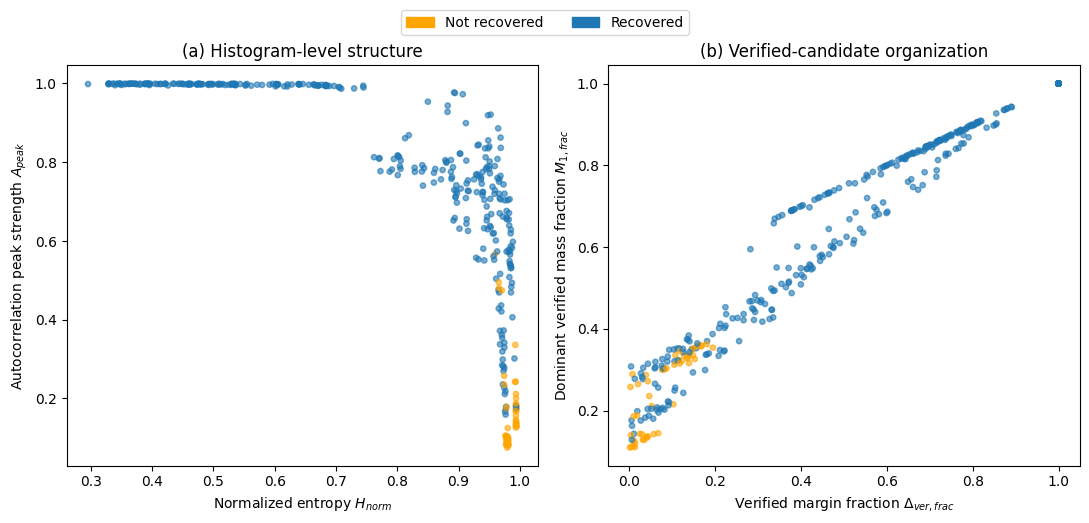

In [22]:
plotRecoverability(backenddf, savename="figure2backend")

In [23]:
backX = backenddf[["Apeak", "Hnorm", "M1frac", "DeltaVerFrac", "skewness", "kurtosis", "numPeaks"]]
backy = backenddf["recoverable"].astype (int)

printSingleFeatureAUROC (backX, backy)

Apeak 0.9865748101042219
Hnorm 0.9349349349349348
M1frac 0.9175646234469763
DeltaVerFrac 0.9112642053818524
skewness 0.756580109521286
kurtosis 0.7924394983218512
numPeaks 0.9412059117941471


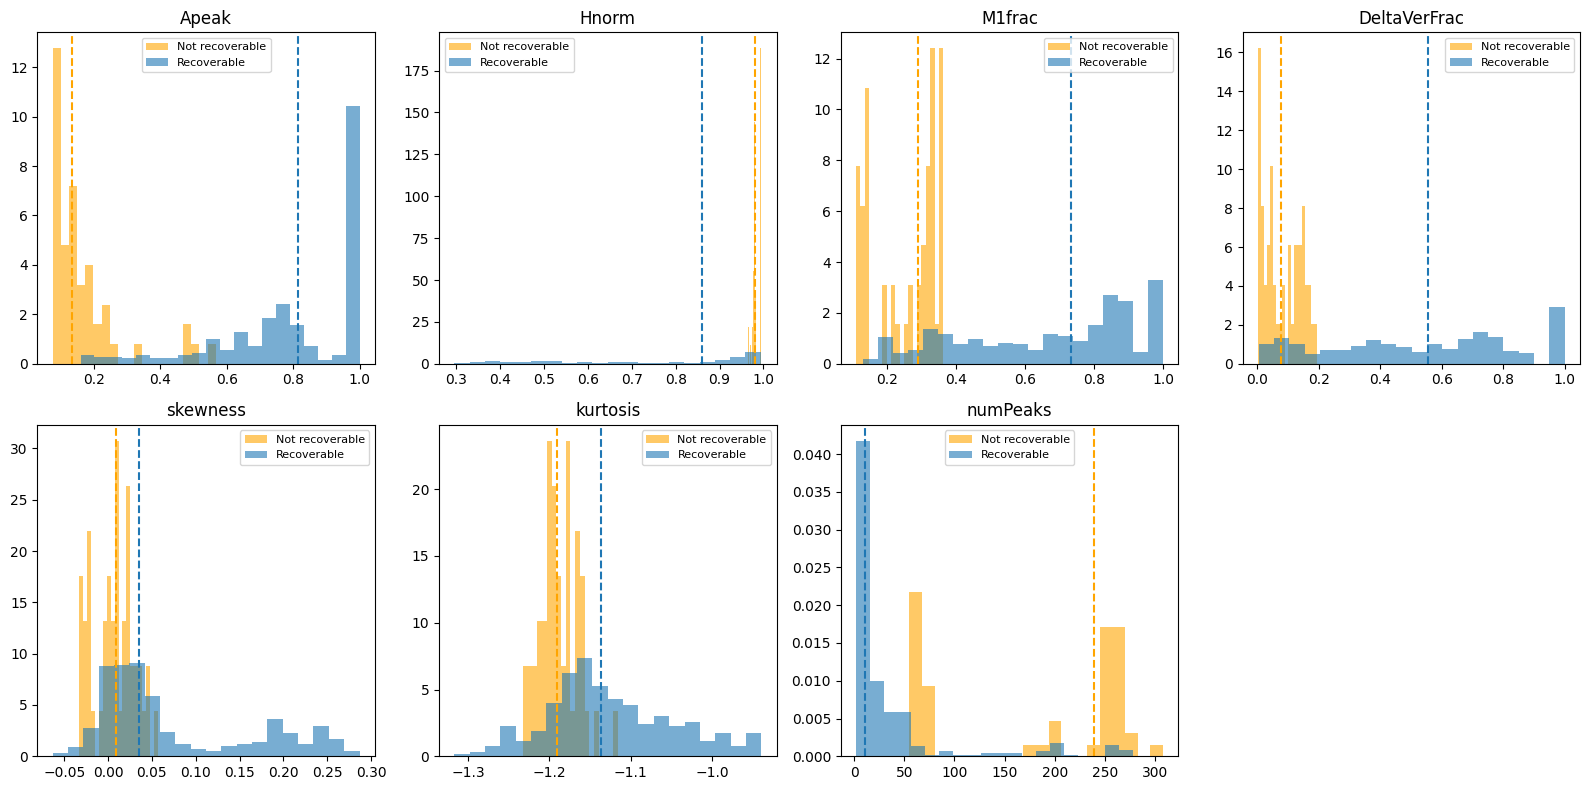

In [25]:
plotMarginalFeatureDistributions (backenddf, features, "figure3backend")

In [26]:
printMultivariableTreeClassifier (backX, backy)

|--- Apeak <= 0.26
|   |--- Hnorm <= 0.98
|   |   |--- M1frac <= 0.28
|   |   |   |--- class: 0
|   |   |--- M1frac >  0.28
|   |   |   |--- class: 1
|   |--- Hnorm >  0.98
|   |   |--- Apeak <= 0.17
|   |   |   |--- class: 0
|   |   |--- Apeak >  0.17
|   |   |   |--- Apeak <= 0.18
|   |   |   |   |--- class: 1
|   |   |   |--- Apeak >  0.18
|   |   |   |   |--- class: 0
|--- Apeak >  0.26
|   |--- M1frac <= 0.14
|   |   |--- M1frac <= 0.13
|   |   |   |--- class: 1
|   |   |--- M1frac >  0.13
|   |   |   |--- class: 0
|   |--- M1frac >  0.14
|   |   |--- Hnorm <= 0.99
|   |   |   |--- DeltaVerFrac <= 0.01
|   |   |   |   |--- class: 1
|   |   |   |--- DeltaVerFrac >  0.01
|   |   |   |   |--- class: 1
|   |   |--- Hnorm >  0.99
|   |   |   |--- class: 0



In [27]:
printInterpretableDecisionTree (backenddf, features, backX, backy)

0.9916426133793841 0.006796892076142487


In [ ]:
means, stds = plotPermutationImportanceFigure(backX, backy, savename="figure5backend")

In [ ]:
for feat in sorted(means, key=means.get, reverse=True):
    print(f"{feat:15s} {means[feat]:.4f} ± {stds[feat]:.4f}")

In [ ]:
# The graphs and data below are for the report

In [ ]:
def getExample (n, feature):

    subset = backenddf[backenddf["N"] == n_choice]

    high_example = subset.loc[subset[feature].idxmax()]
    low_example = subset.loc[subset[feature].idxmin()]
    
    print("High " + feature + ":", high_example[feature], "recoverable:", high_example["recoverable"])
    print("Low " + feature + ":", low_example[feature], "recoverable:", low_example["recoverable"])

    return high_example, low_example

In [ ]:
def plot_distribution(row, title, feature, ax):
    Q = row["Q"]
    counts = row["counts"]
    shots = sum(counts.values())

    p = np.zeros(Q)
    for bitstring, c in counts.items():
        y = int(bitstring, 2)
        p[y] = c / shots

    ax.bar(np.arange(Q), p, width=1.0, color="steelblue")
    ax.set_title(f"{title}\n{feature}={row[feature]:.3f}, recoverable={row['recoverable']}")
    ax.set_xlabel("y")
    ax.set_ylabel("p(y)")

In [ ]:
n_choice = 31
feature = "Apeak"

high, low = getExample (n_choice, feature)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distribution(high, "High " + feature, feature, axes[0])
plot_distribution(low, "Low " + feature, feature, axes[1])
plt.tight_layout()
plt.savefig(feature + "examples.png", dpi=150)
plt.show()

In [ ]:
n_choice = 31
feature = "Hnorm"

high, low = getExample (n_choice, feature)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distribution(low, "Low " + feature, feature, axes[0])
plot_distribution(high, "High " + feature, feature, axes[1])
plt.tight_layout()
plt.savefig(feature + "examples.png", dpi=150)
plt.show()

In [ ]:
n_choice = 31
feature = "M1frac"

high, low = getExample (n_choice, feature)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distribution(high, "High " + feature, feature, axes[0])
plot_distribution(low, "Low " + feature, feature, axes[1])
plt.tight_layout()
plt.savefig(feature + "examples.png", dpi=150)
plt.show()

In [ ]:
n_choice = 63
feature = "DeltaVerFrac"

high, low = getExample (n_choice, feature)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_distribution(high, "High " + feature, feature, axes[0])
plot_distribution(low, "Low " + feature, feature, axes[1])
plt.tight_layout()
plt.savefig(feature + "examples.png", dpi=150)
plt.show()

In [ ]:
def printCountsRecoverability (dataset):
    
    counts = defaultdict(lambda: {"recoverable": 0, "failed": 0})
    
    for exp in dataset:
        n = exp["N"]
        if exp["recoverable"]:
            counts[n]["recoverable"] += 1
        else:
            counts[n]["failed"] += 1

    totalRecoverable = 0
    totalFailed = 0
    
    for n in sorted(counts):
        r = counts[n]["recoverable"]
        f = counts[n]["failed"]
        print(f"N={n}: Recoverable: {r}  Not recoverable: {f}  (total = {r+f})")
        totalRecoverable += r
        totalFailed += f

    total = totalRecoverable + totalFailed
    pct = 100 * totalRecoverable / total if total > 0 else 0
    print(f"\nOverall: Recoverable: {totalRecoverable}  Not recoverable: {totalFailed}  "
          f"(total = {total})  Recoverable %: {pct:.1f}%")

In [ ]:
printCountsRecoverability (simulatorDataset)

In [ ]:
printCountsRecoverability (backendDataset)